# Small-footprint keyword spotting
## 1. Data exploration and preprocessing

This project classifies short recordings into 35 spoken words using Speech Commands v0.02. This notebook explores the audio and prepares **two representations: STFT and MFCC**. Model architectures will be selected in the next stage.

The revised workflow uses the original recordings, 16 kHz mono audio, and one-second inputs. Short clips are center-padded; long clips are truncated. Silence trimming is omitted so that preprocessing is consistent and does not remove part of a word.

**Setup:** put `preprocessing.py` in `src/` and this notebook in `notebooks/`. Install `numpy`, `scipy`, `pandas`, `matplotlib`, `python_speech_features`, and `ipykernel` in your notebook environment. The helper module is separate from the original `utilities.py`; notebooks 2–4 will be migrated when their models are selected.

Extract the complete [Speech Commands v0.02 archive](https://download.tensorflow.org/data/speech_commands_v0.02.tar.gz). Keep `validation_list.txt`, `testing_list.txt`, and `_background_noise_` inside its root, alongside the 35 word folders. The notebook is configured to read the dataset from `data/raw/speech_commands_v0.02/`. The dataset is distributed under CC BY 4.0; retain its license and README.

This revised notebook has cleared outputs: no old results are presented as results of the corrected pipeline.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Works whether Jupyter is launched from the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from preprocessing import (
    SAMPLE_RATE, NUM_SAMPLES, load_audio, pad_or_trim,
    add_background_noise, extract_stft, extract_mfcc, build_manifest,
)

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "speech_commands_v0.02"
SEED = 42
rng = np.random.default_rng(SEED)


## 1. Inventory and fixed dataset splits

We assign file paths to the official splits **before shuffling or adding noise**. The helper checks for missing listed files and overlapping speakers. Training order can be shuffled later without changing which recordings belong to each split.

In [2]:
records, labels = build_manifest(DATA_DIR)
manifest = pd.DataFrame(records)
print(f"{len(manifest):,} recordings across {len(labels)} classes")
print(labels)
display(manifest.groupby("split").agg(recordings=("path", "size"), speakers=("speaker_id", "nunique")))
display(manifest.head())


105,829 recordings across 35 classes
['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


,recordings,speakers
split,,
test,11005,250
train,84843,2112
validation,9981,256


,path,label,label_id,speaker_id,split
0,backward/0165e0e8_nohash_0.wav,backward,0,0165e0e8,train
1,backward/017c4098_nohash_0.wav,backward,0,017c4098,train
2,backward/017c4098_nohash_1.wav,backward,0,017c4098,train
3,backward/017c4098_nohash_2.wav,backward,0,017c4098,train
4,backward/017c4098_nohash_3.wav,backward,0,017c4098,train


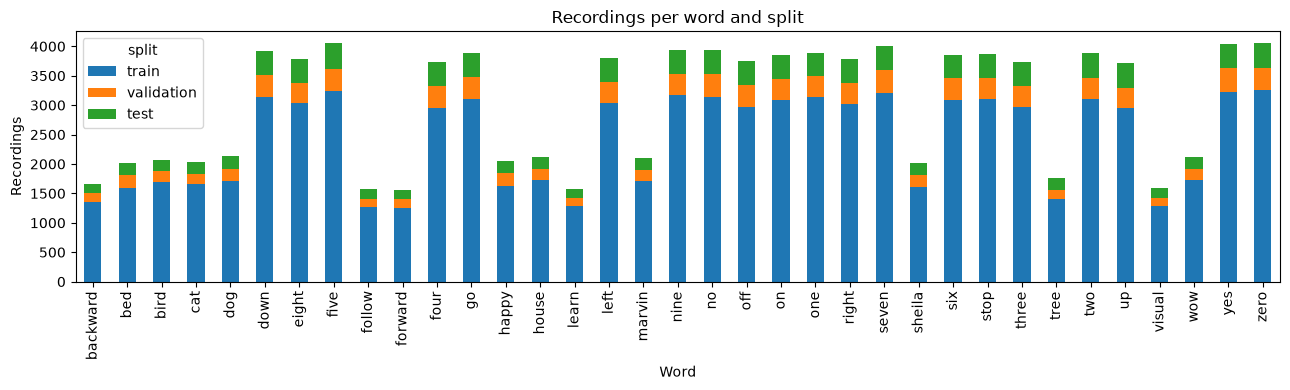

In [3]:
counts = pd.crosstab(manifest["label"], manifest["split"]).reindex(columns=["train", "validation", "test"], fill_value=0)
counts.plot.bar(stacked=True, figsize=(13, 4))
plt.title("Recordings per word and split")
plt.xlabel("Word")
plt.ylabel("Recordings")
plt.tight_layout()
plt.show()


## 2. Audio lengths and example recordings

Use a reproducible sample of training recordings for exploration, avoiding a full dataset scan. Durations below are measured after resampling to 16 kHz, before padding. Loading a clip does not normalize it by its own peak.

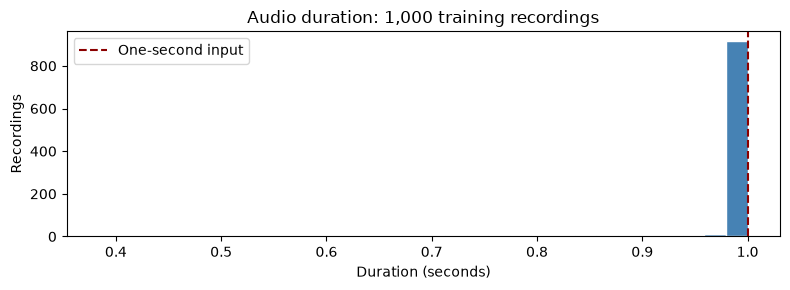

In [4]:
training = manifest.loc[manifest["split"] == "train"]
preview = training.sample(n=min(1000, len(training)), random_state=SEED)
durations = np.array([len(load_audio(DATA_DIR / path)) / SAMPLE_RATE for path in preview["path"]])
plt.figure(figsize=(8, 3))
plt.hist(durations, bins=30, color="steelblue", edgecolor="white")
plt.axvline(1.0, color="darkred", linestyle="--", label="One-second input")
plt.title(f"Audio duration: {len(preview):,} training recordings")
plt.xlabel("Duration (seconds)")
plt.ylabel("Recordings")
plt.legend()
plt.tight_layout()
plt.show()


right/00b01445_nohash_0.wav
Before: 14336 samples; after: 16000 samples


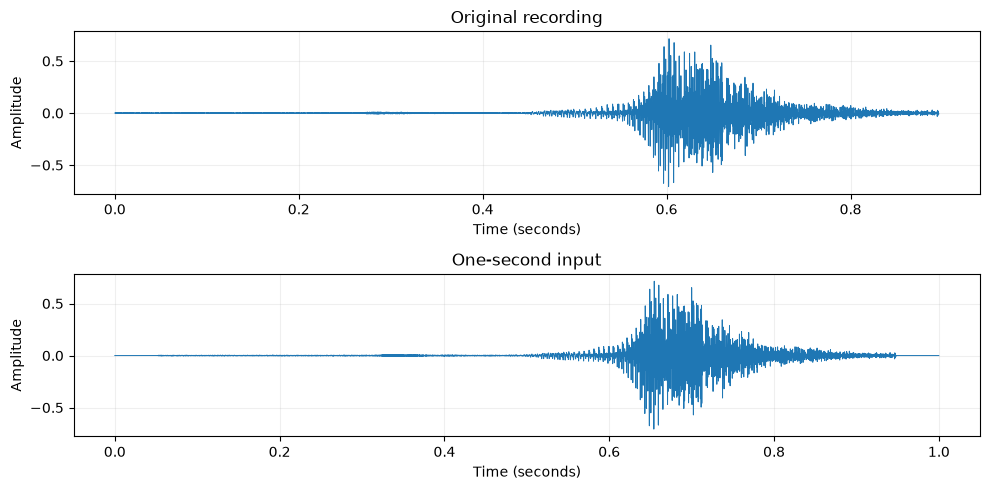

In [5]:
# A training example; change the word or choose a different row to explore.
EXAMPLE_WORD = "right" if "right" in labels else labels[0]
example_row = training.loc[training["label"] == EXAMPLE_WORD].iloc[0]
raw_wave = load_audio(DATA_DIR / example_row["path"])
wave = pad_or_trim(raw_wave)
print(example_row["path"])
print(f"Before: {len(raw_wave)} samples; after: {len(wave)} samples")
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
for ax, signal, title in zip(axes, [raw_wave, wave], ["Original recording", "One-second input"]):
    ax.plot(np.arange(len(signal)) / SAMPLE_RATE, signal, linewidth=0.7)
    ax.set(title=title, xlabel="Time (seconds)", ylabel="Amplitude")
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
display(Audio(wave, rate=SAMPLE_RATE, normalize=False))


## 3. STFT and MFCC

- **STFT:** magnitude of the short-time Fourier transform, using a 256-sample periodic Hann window and a 128-sample step. Output: `(124, 129, 1)`.
- **MFCC:** 13 cepstral coefficients, 26 internal Mel filters, 25 ms Hamming windows and a 10 ms step. Output: `(99, 13, 1)`. The Mel filters are part of computing MFCC; they are not a separate experiment.

Both arrays use **(time, feature, channel)**. Their dimensions differ, but their axis conventions agree. We use a logarithmic scale only to display STFT; the model input remains the magnitude representation used in the original training notebook.

References: [TensorFlow STFT framing](https://www.tensorflow.org/api_docs/python/tf/signal/stft) and [python_speech_features MFCC](https://python-speech-features.readthedocs.io/en/latest/).

STFT: (124, 129, 1) float32
MFCC: (99, 13, 1) float32


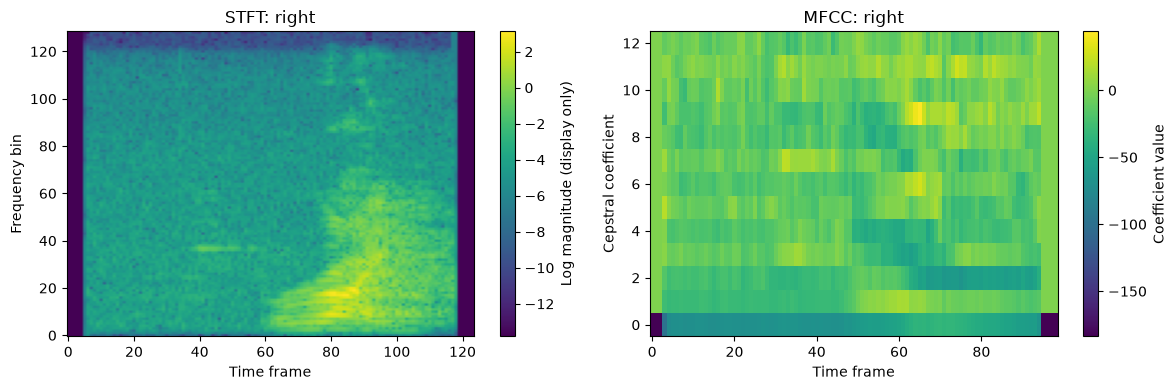

In [6]:
stft_features = extract_stft(wave)
mfcc_features = extract_mfcc(wave)
print("STFT:", stft_features.shape, stft_features.dtype)
print("MFCC:", mfcc_features.shape, mfcc_features.dtype)
assert stft_features.shape == (124, 129, 1)
assert mfcc_features.shape == (99, 13, 1)
assert np.isfinite(stft_features).all() and np.isfinite(mfcc_features).all()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
a = axes[0].imshow(np.log(stft_features[:, :, 0].T + 1e-6), origin="lower", aspect="auto")
axes[0].set(title=f"STFT: {EXAMPLE_WORD}", xlabel="Time frame", ylabel="Frequency bin")
fig.colorbar(a, ax=axes[0], label="Log magnitude (display only)")
b = axes[1].imshow(mfcc_features[:, :, 0].T, origin="lower", aspect="auto")
axes[1].set(title=f"MFCC: {EXAMPLE_WORD}", xlabel="Time frame", ylabel="Cepstral coefficient")
fig.colorbar(b, ax=axes[1], label="Coefficient value")
plt.tight_layout()
plt.show()


## 4. Optional background noise

This cell demonstrates augmentation on the training example. Noise is selected by filename and a random segment is mixed into the recording. The scale is an amplitude multiplier, not a signal-to-noise ratio in dB. The mixed waveform is clipped to the valid audio range.

For later training, augment only training clips. Keep validation and test data unchanged for the main comparison. Any noisy evaluation should be a separately defined, reproducible experiment.

/home/stefano98/projects/speech-command-recognition/src/preprocessing.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, wave = wavfile.read(path)


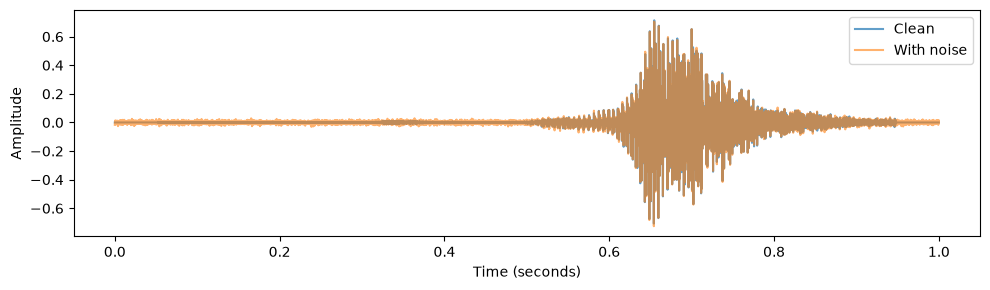

Noisy STFT: (124, 129, 1)
Noisy MFCC: (99, 13, 1)


In [8]:
APPLY_NOISE = True
NOISE_FILE = DATA_DIR / "_background_noise_" / "doing_the_dishes.wav"
NOISE_SCALE = 0.2

if APPLY_NOISE:
    noisy_wave = add_background_noise(wave, NOISE_FILE, scale=NOISE_SCALE, rng=np.random.default_rng(SEED))
    plt.figure(figsize=(10, 3))
    times = np.arange(NUM_SAMPLES) / SAMPLE_RATE
    plt.plot(times, wave, label="Clean", alpha=0.7)
    plt.plot(times, noisy_wave, label="With noise", alpha=0.6)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()
    display(Audio(noisy_wave, rate=SAMPLE_RATE, normalize=False))
    print("Noisy STFT:", extract_stft(noisy_wave).shape)
    print("Noisy MFCC:", extract_mfcc(noisy_wave).shape)
else:
    print("Noise augmentation is off. Set APPLY_NOISE = True to preview it.")


## 5. Save the inventory for the next stage

Save relative file paths and the label order, rather than materializing every feature array in memory. The model notebooks must load this fixed split and the same helpers from `src/preprocessing.py` when we revise them. Fit any learned normalization on training data only.

No model is trained here. The old training outputs need to be rerun after those notebooks are updated; they are not results of this revised preprocessing.

In [9]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
manifest.to_csv(OUTPUT_DIR / "speech_commands_manifest.csv", index=False)
(OUTPUT_DIR / "labels.json").write_text(json.dumps(labels, indent=2) + "\n")
print(f"Saved manifest and class order to {OUTPUT_DIR.resolve()}")


Saved manifest and class order to /home/stefano98/projects/speech-command-recognition/data/processed
